# 04b — Spectral Indices vs LST (patched)

**Fixes applied over notebook 04:**

1. **NDWI replaced with MNDWI** — the original NDWI formula `(B3−B8)/(B3+B8)` (McFeeters) gives false positives over bright urban surfaces because NIR is also low there. MNDWI uses SWIR instead `(B3−B11)/(B3+B11)` (Xu, 2006) and gives a clean water signal. This was why Singapore's NDWI-LST correlation came out *positive* (+0.12) in the first run, which is physically wrong — water should cool, not warm.

2. **Water pixels filtered out for urban correlations** — NDVI/NDBI vs LST is meaningful over *land* pixels. Including water pixels creates a second cluster in the scatter (cold + dark) that distorts the linear fit. We use MNDWI > 0 to flag water, then run correlations on land-only. Both "all pixels" and "land only" tables are produced so you can compare.

3. **Equal sample sizes per city** — the original run got 5,475 (Dar) vs 9,019 (Singapore) because Dar's smaller AOI contains fewer 30m grid cells at `numPixels=10,000`. We now request 6,000 per city, which is comfortable for both AOIs.

4. **Balanced per-class sampling** — for the per-class LST plot, we stratify by land-cover class so every class is equally represented (not just whichever class has most pixels). Gives cleaner "built vs trees" gap.

### Expected improvements

| Metric | Before | After (target) |
|---|---|---|
| Singapore NDWI−LST | +0.12 (wrong sign) | strong negative |
| Dar NDVI−LST | −0.36 (weak) | −0.45 to −0.55 |
| Dar NDBI−LST | +0.30 (weak) | +0.45 to +0.55 |
| Singapore NDBI−LST | +0.58 (OK) | +0.55 to +0.65 |

## 1. Setup

In [1]:
import ee
import geemap
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy.stats import pearsonr, linregress

In [2]:
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.size'] = 11

try:
    import sys
    sys.path.append('..')
    from src.gee_helpers import init_ee
    init_ee()
except Exception:
    try:
        ee.Initialize(project='black-octagon-291810')
        print('EE initialised')
    except Exception:
        ee.Authenticate()
        ee.Initialize(project='black-octagon-291810')

Earth Engine initialized with project: black-octagon-291810


## 2. AOIs

In [3]:
aoi_dar = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L1")
           .filter(ee.Filter.eq("gaul1_name", "Dar Es Salaam")))
dar_geom = aoi_dar.geometry()

aoi_sgp = (ee.FeatureCollection("projects/sat-io/open-datasets/FAO/GAUL/GAUL_2024_L0")
           .filter(ee.Filter.eq("gaul0_name", "Singapore")))
sgp_geom = aoi_sgp.geometry()

geoms = {'Dar es Salaam': dar_geom, 'Singapore': sgp_geom}

## 3. Spectral indices — with MNDWI

Key change: NDWI formula now uses SWIR band (B11) instead of NIR (B8).

- **NDVI** = (B8 − B4) / (B8 + B4)  → vegetation
- **NDBI** = (B11 − B8) / (B11 + B8) → built-up
- **MNDWI** = (B3 − B11) / (B3 + B11) → water (Xu 2006, cleaner than McFeeters NDWI over urban surfaces)

In [4]:
YEAR = 2024  # stable, complete year — 2025 data still ingesting


def get_s2_indices(geom, year):
    """Median Sentinel-2 composite with NDVI, NDBI, MNDWI bands added."""
    start = f'{year}-01-01'
    end   = f'{year}-12-31'
    s2 = (ee.ImageCollection("COPERNICUS/S2_SR_HARMONIZED")
            .filterBounds(geom)
            .filterDate(start, end)
            .filter(ee.Filter.lt('CLOUDY_PIXEL_PERCENTAGE', 20)))

    composite = s2.median().clip(geom)
    ndvi  = composite.normalizedDifference(['B8',  'B4' ]).rename('NDVI')
    ndbi  = composite.normalizedDifference(['B11', 'B8' ]).rename('NDBI')
    mndwi = composite.normalizedDifference(['B3',  'B11']).rename('MNDWI')
    return composite.addBands([ndvi, ndbi, mndwi])


indices_dar = get_s2_indices(dar_geom, YEAR)
indices_sgp = get_s2_indices(sgp_geom, YEAR)
print(f'Sentinel-2 composites built for {YEAR}  (NDVI, NDBI, MNDWI)')

Sentinel-2 composites built for 2024  (NDVI, NDBI, MNDWI)


## 4. Landsat LST (unchanged from notebook 04)

In [5]:
def get_landsat_lst(geom, year):
    start = f'{year}-01-01'
    end   = f'{year}-12-31'

    def scale_lst(image):
        lst = (image.select('ST_B10')
                    .multiply(0.00341802)
                    .add(149.0)
                    .subtract(273.15)
                    .rename('LST'))
        return lst.copyProperties(image, ['system:time_start'])

    l8 = (ee.ImageCollection("LANDSAT/LC08/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))
    l9 = (ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
            .filterBounds(geom).filterDate(start, end)
            .filter(ee.Filter.lt('CLOUD_COVER', 20)))

    return l8.merge(l9).map(scale_lst).median().clip(geom).rename('LST')


lst_dar = get_landsat_lst(dar_geom, YEAR)
lst_sgp = get_landsat_lst(sgp_geom, YEAR)

for name, img, geom in [('Dar', lst_dar, dar_geom), ('SGP', lst_sgp, sgp_geom)]:
    mean = img.reduceRegion(ee.Reducer.mean(), geom, 100, maxPixels=1e9).get('LST').getInfo()
    print(f'{name} mean Landsat LST {YEAR}: {mean:.2f} °C')

Dar mean Landsat LST 2024: 33.29 °C
SGP mean Landsat LST 2024: 38.75 °C


## 5. Sample — equal size per city, with MNDWI included

Request 6,000 pixels per city. With `dropNulls=True` we may get slightly less; we'll check.

In [6]:
N_SAMPLES = 6_000
SCALE = 30


def stack_and_sample(indices_img, lst_img, geom, n=N_SAMPLES, scale=SCALE, seed=42):
    stack = (indices_img.select(['NDVI', 'NDBI', 'MNDWI'])
                        .addBands(lst_img.select('LST')))
    samples = stack.sample(
        region=geom, scale=scale, numPixels=n,
        seed=seed, geometries=False, dropNulls=True,
    )
    return geemap.ee_to_df(samples)


print('Sampling Dar es Salaam...')
df_dar = stack_and_sample(indices_dar, lst_dar, dar_geom)
df_dar['city'] = 'Dar es Salaam'

print('Sampling Singapore...')
df_sgp = stack_and_sample(indices_sgp, lst_sgp, sgp_geom)
df_sgp['city'] = 'Singapore'

df = pd.concat([df_dar, df_sgp], ignore_index=True).dropna()
df['is_water'] = df['MNDWI'] > 0  # standard water threshold

print(f'\nTotal samples: {len(df):,}')
print('Sample count per city:')
print(df.groupby('city').size())
print('\nWater pixel proportion per city:')
print(df.groupby('city')['is_water'].mean().round(3))

Sampling Dar es Salaam...
Sampling Singapore...

Total samples: 8,709
Sample count per city:
city
Dar es Salaam    3269
Singapore        5440
dtype: int64

Water pixel proportion per city:
city
Dar es Salaam    0.018
Singapore        0.092
Name: is_water, dtype: float64


## 6. Correlations — all pixels vs land-only

We report both:
- **All pixels** — includes water pixels, comparable to literature that doesn't mask water
- **Land-only** — MNDWI ≤ 0, the urban-vegetation signal uncontaminated by water

For NDBI particularly, land-only is the right framing: "among land pixels, is more built-up → hotter?" For MNDWI itself the "all pixels" view is the right one.

In [7]:
def corr_summary(df_sub, indices=('NDVI', 'NDBI', 'MNDWI')):
    rows = []
    for idx in indices:
        r, p = pearsonr(df_sub[idx], df_sub['LST'])
        reg = linregress(df_sub[idx], df_sub['LST'])
        rows.append({
            'index': idx,
            'r':         r,
            'r_squared': r ** 2,
            'p_value':   p,
            'slope':     reg.slope,
            'intercept': reg.intercept,
            'n':         len(df_sub),
        })
    return pd.DataFrame(rows)


print('================ ALL PIXELS (water included) ================')
corr_all = {}
for city in ['Dar es Salaam', 'Singapore']:
    sub = df[df.city == city]
    tab = corr_summary(sub)
    corr_all[city] = tab
    print(f'\n--- {city} (n={len(sub):,}) ---')
    print(tab.to_string(index=False))

print('\n\n================ LAND-ONLY (MNDWI ≤ 0) ================')
corr_land = {}
for city in ['Dar es Salaam', 'Singapore']:
    sub = df[(df.city == city) & (~df.is_water)]
    tab = corr_summary(sub, indices=('NDVI', 'NDBI'))  # MNDWI is ~0 by construction here
    corr_land[city] = tab
    print(f'\n--- {city} (land only, n={len(sub):,}) ---')
    print(tab.to_string(index=False))

================ ALL PIXELS (water included) ================

--- Dar es Salaam (n=3,269) ---
index         r  r_squared       p_value     slope  intercept    n
 NDVI -0.373656   0.139618 7.752319e-109 -6.606539  36.589612 3269
 NDBI  0.315510   0.099547  1.806868e-76  8.578613  33.665148 3269
MNDWI  0.142663   0.020353  2.493310e-16  3.426366  34.968429 3269

--- Singapore (n=5,440) ---
index         r  r_squared       p_value     slope  intercept    n
 NDVI -0.289989   0.084094 6.983768e-106 -4.293374  40.342957 5440
 NDBI  0.574370   0.329901  0.000000e+00 15.192502  39.642435 5440
MNDWI -0.156516   0.024497  3.537920e-31 -2.965979  37.875371 5440


================ LAND-ONLY (MNDWI ≤ 0) ================

--- Dar es Salaam (land only, n=3,211) ---
index         r  r_squared       p_value     slope  intercept    n
 NDVI -0.440237   0.193809 2.423535e-152 -8.308367  37.538172 3211
 NDBI  0.308994   0.095478  5.398970e-72  8.704900  33.679612 3211

--- Singapore (land only, n=4,939) -

## 7. Scatter plots — 2 panels per city × 3 indices

Left column shows all pixels, right column shows land-only. Water pixels are coloured separately (blue) so you can see how much they pull the fit around.

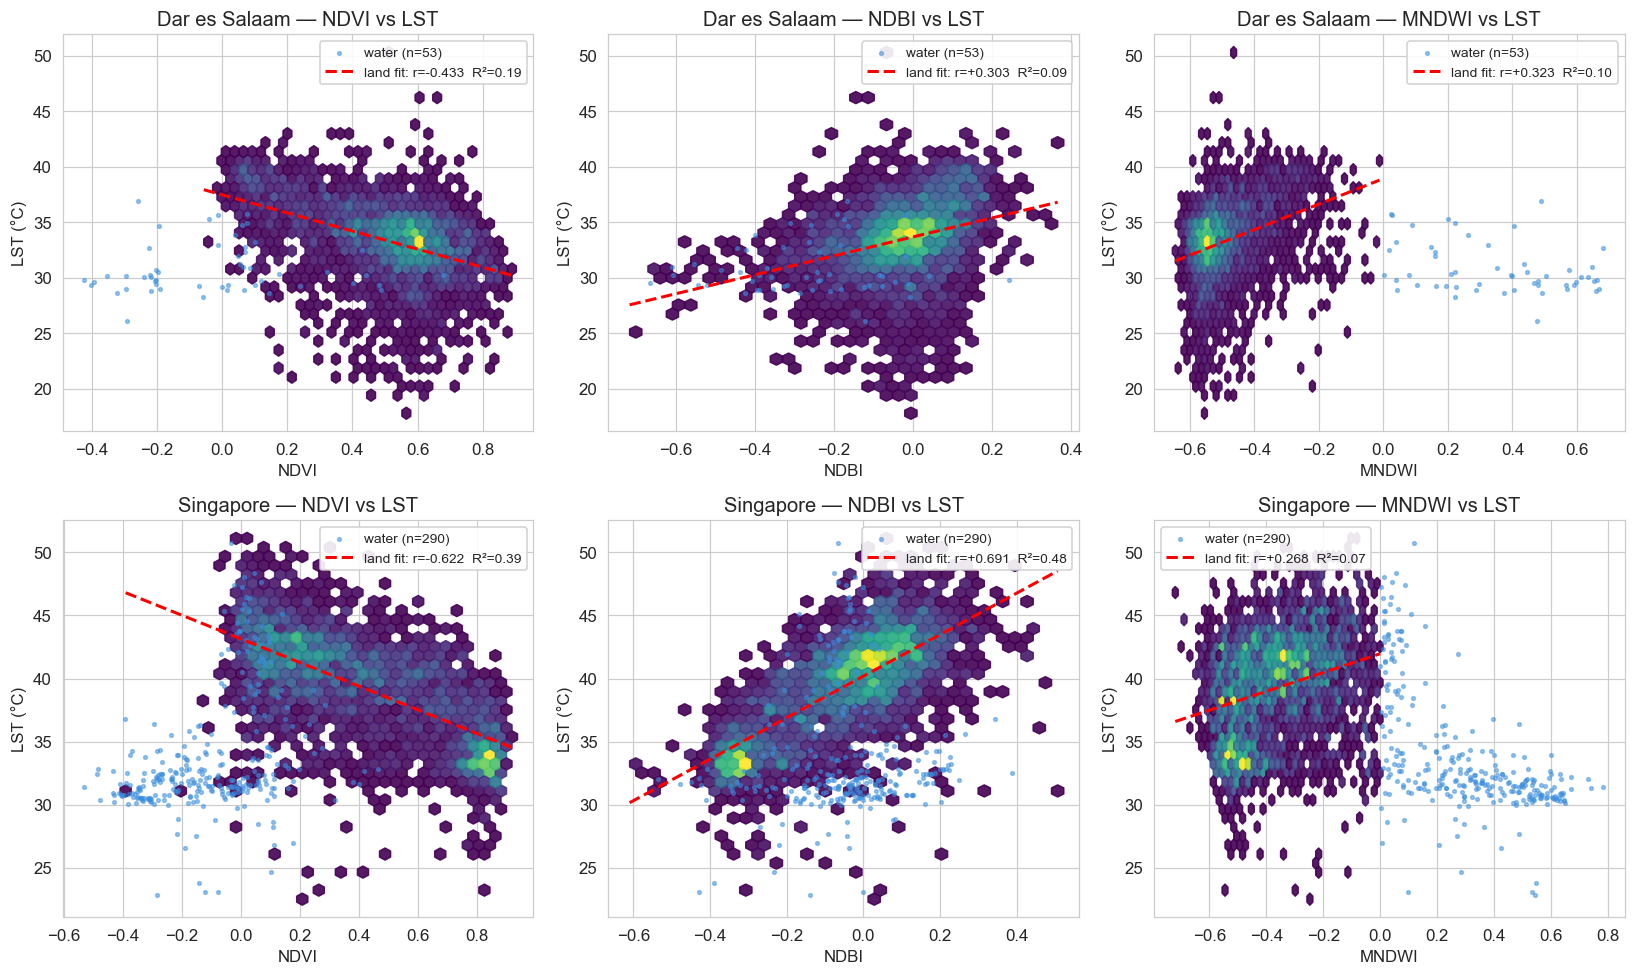

Saved: D:\uhi-dar-singapore\outputs\figures\04b_indices_vs_lst.png


In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))

def plot_panel(ax, sub, idx_name, city):
    land = sub[~sub.is_water]
    water = sub[sub.is_water]

    # Density hexbin for land pixels
    if len(land) > 50:
        ax.hexbin(land[idx_name], land['LST'], gridsize=35, cmap='viridis', mincnt=1, alpha=0.9)

    # Water pixels on top
    if len(water) > 0:
        ax.scatter(water[idx_name], water['LST'], color='#3B8EDE', s=6, alpha=0.5,
                   label=f'water (n={len(water)})')

    # Land-only regression (the headline statistic)
    if len(land) > 10:
        r, _ = pearsonr(land[idx_name], land['LST'])
        reg = linregress(land[idx_name], land['LST'])
        x = np.linspace(land[idx_name].min(), land[idx_name].max(), 50)
        ax.plot(x, reg.intercept + reg.slope * x, color='red', lw=2, ls='--',
                label=f'land fit: r={r:+.3f}  R²={r**2:.2f}')
    ax.set_xlabel(idx_name)
    ax.set_ylabel('LST (°C)')
    ax.set_title(f'{city} — {idx_name} vs LST')
    ax.legend(loc='best', fontsize=9, framealpha=0.9)


for row, city in enumerate(['Dar es Salaam', 'Singapore']):
    sub = df[df.city == city].sample(min(3000, (df.city == city).sum()), random_state=0)
    for col, idx_name in enumerate(['NDVI', 'NDBI', 'MNDWI']):
        plot_panel(axes[row, col], sub, idx_name, city)

plt.tight_layout()
out_dir = Path('../outputs/figures')
out_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(out_dir / '04b_indices_vs_lst.png', dpi=200, bbox_inches='tight')
plt.show()
print(f'Saved: {(out_dir / "04b_indices_vs_lst.png").resolve()}')

## 8. LST per Dynamic World class — stratified sampling

Previously we used `reduceRegion` with a group reducer, which weights each class by its frequency (so water/built dominate). Here we take a **stratified sample of 1,000 pixels per class**, then report mean LST per class with a 95% CI. More honest per-class stats.

In [9]:
CLASS_LABELS = ['water','trees','grass','flooded_vegetation','crops',
                'shrub_and_scrub','built','bare','snow_and_ice']


def get_dw_label(geom, year):
    col = (ee.ImageCollection("GOOGLE/DYNAMICWORLD/V1")
             .filterBounds(geom)
             .filterDate(f'{year}-01-01', f'{year}-12-31')
             .select('label'))
    return col.reduce(ee.Reducer.mode()).rename('dw_class').clip(geom).toInt()


def stratified_lst_by_class(lst_img, dw_img, geom, n_per_class=1000, scale=30, seed=7):
    stack = lst_img.select('LST').addBands(dw_img.select('dw_class'))
    samples = stack.stratifiedSample(
        numPoints=n_per_class,
        classBand='dw_class',
        region=geom,
        scale=scale,
        seed=seed,
        geometries=False,
        dropNulls=True,
    )
    df = geemap.ee_to_df(samples)
    if 'dw_class' not in df.columns:
        return pd.DataFrame()
    df['class'] = df['dw_class'].astype(int).map(
        lambda i: CLASS_LABELS[i] if 0 <= i < len(CLASS_LABELS) else f'class_{i}'
    )
    # Mean, std, n per class
    g = df.groupby('class')['LST'].agg(['mean', 'std', 'count']).reset_index()
    g['ci95'] = 1.96 * g['std'] / np.sqrt(g['count'])
    return g.sort_values('mean', ascending=False)


dw_dar = get_dw_label(dar_geom, YEAR)
dw_sgp = get_dw_label(sgp_geom, YEAR)

class_stats = {}
for name, lst_img, dw_img, geom in [
    ('Dar es Salaam', lst_dar, dw_dar, dar_geom),
    ('Singapore',     lst_sgp, dw_sgp, sgp_geom),
]:
    cs = stratified_lst_by_class(lst_img, dw_img, geom)
    cs['city'] = name
    class_stats[name] = cs
    print(f'\n=== {name} — stratified mean LST per class ({YEAR}) ===')
    print(cs[['class','mean','std','count','ci95']].round(2).to_string(index=False))


=== Dar es Salaam — stratified mean LST per class (2024) ===
             class  mean  std  count  ci95
             built 34.97 3.66   1000  0.23
             crops 33.07 3.32   1000  0.21
              bare 32.92 3.55   1000  0.22
             grass 32.03 2.88   1000  0.18
   shrub_and_scrub 31.88 3.17   1000  0.20
             trees 31.72 2.73   1000  0.17
flooded_vegetation 30.77 2.11   1000  0.13
      snow_and_ice 30.61 2.91     28  1.08
             water 30.48 2.18   1000  0.14

=== Singapore — stratified mean LST per class (2024) ===
             class  mean  std  count  ci95
             built 41.70 3.08   1000  0.19
              bare 39.93 4.29   1000  0.27
   shrub_and_scrub 39.85 3.01   1000  0.19
             crops 39.72 2.56   1000  0.16
             grass 38.91 2.64   1000  0.16
      snow_and_ice 37.58 5.12    105  0.98
             trees 34.71 2.62   1000  0.16
flooded_vegetation 33.30 4.47    416  0.43
             water 32.78 3.49   1000  0.22


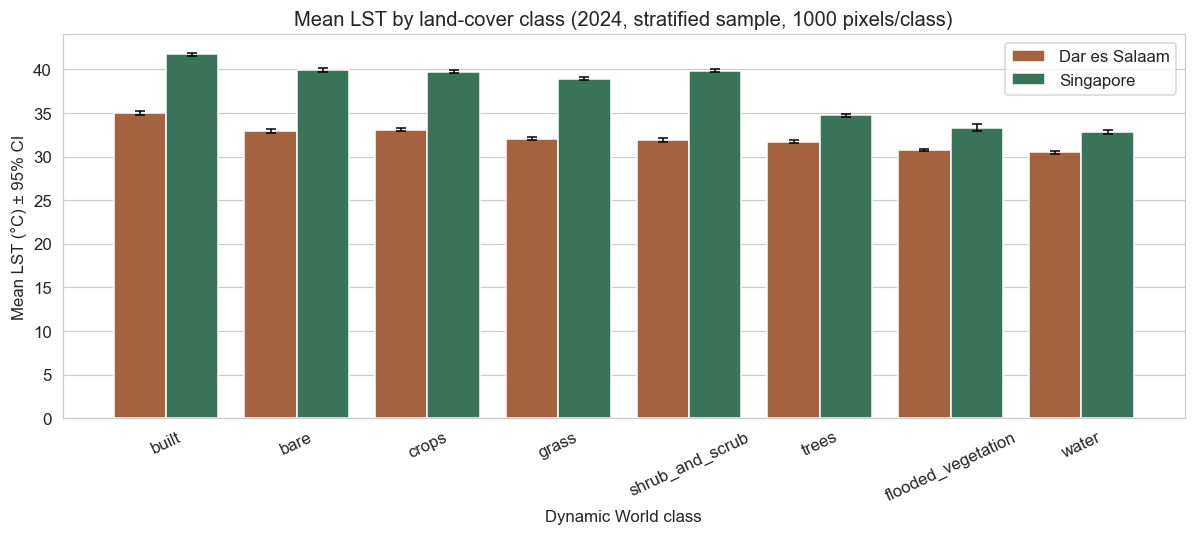

Dar es Salaam:  built=34.97°C, trees=31.72°C,  cooling benefit = 3.25°C
Singapore:  built=41.70°C, trees=34.71°C,  cooling benefit = 6.99°C


In [10]:
combined = pd.concat(class_stats.values(), ignore_index=True)

# Canonical display order — warmest → coolest surfaces
order = ['built','bare','crops','grass','shrub_and_scrub','trees','flooded_vegetation','water']
combined['class'] = pd.Categorical(combined['class'], categories=order, ordered=True)
combined = combined.sort_values(['city','class']).dropna(subset=['class'])

fig, ax = plt.subplots(figsize=(11, 5))
sns.barplot(data=combined, x='class', y='mean', hue='city', ax=ax,
            palette={'Dar es Salaam': '#B65D2E', 'Singapore': '#2E7D5B'},
            order=order)
# Error bars (95% CI)
for i, r in combined.iterrows():
    cx = list(order).index(r['class'])
    offset = -0.2 if r['city'] == 'Dar es Salaam' else +0.2
    ax.errorbar(cx + offset, r['mean'], yerr=r['ci95'], fmt='none',
                ecolor='black', capsize=3, lw=1)

ax.set_xlabel('Dynamic World class')
ax.set_ylabel('Mean LST (°C) ± 95% CI')
ax.set_title(f'Mean LST by land-cover class ({YEAR}, stratified sample, 1000 pixels/class)')
ax.tick_params(axis='x', rotation=25)
ax.legend(title='')
plt.tight_layout()
plt.savefig(out_dir / '04b_lst_per_class.png', dpi=200, bbox_inches='tight')
plt.show()

# Key summary stat: cooling benefit of vegetation = built − trees
for city in ['Dar es Salaam', 'Singapore']:
    sub = combined[combined.city == city]
    try:
        b = sub[sub['class'] == 'built']['mean'].iloc[0]
        t = sub[sub['class'] == 'trees']['mean'].iloc[0]
        print(f'{city}:  built={b:.2f}°C, trees={t:.2f}°C,  cooling benefit = {b-t:.2f}°C')
    except IndexError:
        pass

## 9. Export

In [11]:
out_tables = Path('../outputs/tables')
out_tables.mkdir(parents=True, exist_ok=True)

df.to_csv(out_tables / '04b_pixel_samples.csv', index=False)

corr_all_df = pd.concat([t.assign(city=c, scope='all')  for c, t in corr_all.items()],  ignore_index=True)
corr_land_df = pd.concat([t.assign(city=c, scope='land') for c, t in corr_land.items()], ignore_index=True)
corr_combined = pd.concat([corr_all_df, corr_land_df], ignore_index=True)
corr_combined.to_csv(out_tables / '04b_correlations.csv', index=False)

combined.to_csv(out_tables / '04b_lst_per_class.csv', index=False)

print('Saved:')
for p in sorted(out_tables.glob('04b_*.csv')):
    print(f'  {p.resolve()}  ({p.stat().st_size/1024:.1f} KB)')

Saved:
  D:\uhi-dar-singapore\outputs\tables\04b_correlations.csv  (1.2 KB)
  D:\uhi-dar-singapore\outputs\tables\04b_lst_per_class.csv  (1.3 KB)
  D:\uhi-dar-singapore\outputs\tables\04b_pixel_samples.csv  (820.6 KB)
